<a href="https://colab.research.google.com/github/NinoUAM/ECM_2526_FinalProject_Gr12/blob/main/Code_Final_Eq12_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prédiction de Succès en Biopharma & Analyse Éthique
**Équipe 12** — Nino Tissot · Audrey Nourry · Mailis Briens · Hajar Belgroun

Section 1 — Chargement et EDA
Le notebook commence par charger le dataset investments_VC.csv qui contient l'ensemble des startups issues de bases de données de capital-risque. Deux colonnes mal nommées (avec des espaces) sont renommées proprement. Ensuite un filtre est appliqué pour ne garder que les entreprises du secteur pharma/biotech : on cherche les mots-clés "pharma", "biotech", "therapeutics", "clinical", etc. dans les colonnes category_list et market. On passe de l'ensemble du dataset à environ 4 030 entités sectorielles.
La colonne funding_total_usd est nettoyée : suppression des virgules, remplacement des tirets par des valeurs manquantes, conversion en numérique. Sans cette étape la colonne reste en format texte et tous les calculs financiers échouent.
L'EDA produit quatre graphiques : la répartition des statuts (operating, acquired, closed, ipo), le top 10 des pays d'origine, la distribution du financement total en échelle logarithmique (car les montants varient de quelques milliers à plusieurs milliards), et la distribution du nombre de rounds de financement. Ces visualisations permettent de comprendre la structure du dataset avant toute modélisation.

Section 2 — Feature Engineering
C'est la partie la plus importante du projet. Plutôt que d'utiliser les variables brutes du dataset, on construit des variables qui traduisent directement la logique d'un investisseur.
La date de coupure est fixée au 01/01/2012. On ne garde pour l'entraînement que les startups fondées avant cette date et dont le statut est définitivement tranché (acquired, ipo ou closed). Les startups encore en activité sont mises de côté pour être scorées plus tard. Cela évite le data leakage : le modèle apprend sur le passé et prédit sur le présent.
Les variables construites sont les suivantes. age est le nombre d'années entre la fondation et la date de coupure. days_to_first_funding est le délai en jours entre la fondation et le premier tour de financement — une startup qui lève vite est un signal positif. funding_duration est la durée totale de l'activité de levée de fonds, plafonnée à la date de coupure pour éviter d'utiliser des informations futures. funding_velocity est le montant total levé divisé par l'âge — mesure la capacité à lever rapidement. round_intensity est le nombre de rounds divisé par l'âge — mesure la régularité à attirer des investisseurs. Cinq variables binaires indiquent si la startup a obtenu chaque type de financement (seed, venture, grant, round_A, round_B).
Les valeurs manquantes sont imputées par la médiane sectorielle (groupby market) plutôt que par la médiane globale, pour préserver les différences entre sous-secteurs. Les pays peu représentés (moins de 10 occurrences) sont regroupés sous "OTHER". Un pipeline scikit-learn (SimpleImputer + StandardScaler) est appliqué avant chaque modèle.
La variable cible Profitable vaut 1 pour acquired ou ipo, 0 pour closed. L'échantillon final est de 272 startups avec 145 succès (53,3%) et 127 échecs — quasi-équilibré, ce qui permet d'entraîner sans rééchantillonnage artificiel.
Trois boxplots comparent les distributions de funding_velocity, round_intensity et days_to_first_funding entre succès et échecs, pour vérifier visuellement que ces variables ont bien un pouvoir discriminant.

Section 3 — Modèles ML Baseline
Quatre algorithmes sont entraînés et comparés. Tous utilisent class_weight='balanced' pour traiter équitablement les deux classes. Pour chaque modèle, une cross-validation à 5 folds est effectuée sur le train set pour obtenir un F1 moyen et son écart-type — bien plus fiable que le simple score sur 54 exemples de test. Le modèle est ensuite entraîné sur tout le train set et évalué sur le test set (Accuracy, Précision, Recall, F1).
La Logistic Regression sert de baseline linéaire. Le Random Forest capture des relations non-linéaires entre features. Le Gradient Boosting (HistGradientBoostingClassifier, version moderne et rapide) est le plus performant sur nos données avec un F1 de 63,3%. Le SVM présente la meilleure précision parmi les modèles de base, comportement conservateur utile pour limiter les faux positifs.
Une matrice de confusion est affichée pour le Gradient Boosting, permettant de voir concrètement combien de succès et d'échecs sont bien ou mal classés. Un graphique d'importance des features du Random Forest montre quelles variables pèsent le plus dans les prédictions — typiquement funding_velocity et funding_total_usd ressortent en tête.

Section 4 — Optimisation du Gradient Boosting
Un GridSearchCV teste toutes les combinaisons de trois hyperparamètres sur le Gradient Boosting : max_iter (100 ou 200 arbres), max_depth (profondeur 3, 5 ou 7) et learning_rate (0.05, 0.1 ou 0.2). La recherche est faite en cross-validation à 5 folds avec comme métrique le F1-Score. Le meilleur jeu de paramètres est affiché et le modèle tuné est évalué sur le test set pour comparer avec la baseline.

Section 5 — StackingClassifier
Au lieu de simplement moyenner les probabilités des 4 modèles, un StackingClassifier est construit. Les 4 modèles de base (Logistic Regression, Random Forest, Gradient Boosting, SVM) génèrent chacun leurs prédictions en cross-validation (out-of-fold), et une Logistic Regression finale apprend à combiner ces prédictions de façon optimale. Cela revient à laisser les données décider des poids à donner à chaque modèle plutôt que de les fixer arbitrairement à 25% chacun.

Section 6 — Scoring du portefeuille
Les modèles entraînés sont appliqués aux startups encore en activité ("operating"). Le même pipeline de feature engineering est appliqué avec les paramètres appris sur le train set (même pays rares, même scaler). Pour chaque startup on calcule le score stacking. Les résultats sont triés par score stacking décroissant et exportés dans startups_scoring_final.csv. Le top 10 des startups les plus prometteuses est affiché.

Section 7 — Pipeline NLP (ESG-BERT)
Un pipeline de collecte de données textuelles est construit autour de trois sources. ClinicalTrials.gov est interrogé via son API v2 pour trouver tous les essais cliniques terminés où la startup apparaît comme sponsor principal ou collaborateur. PubMed est interrogé via l'API Entrez pour trouver les publications scientifiques affiliées à la startup, dont les titres et abstracts sont récupérés. Les sites web des entreprises sont scrapés en essayant automatiquement plusieurs paths courants (/about, /company, /about-us, etc.) pour extraire les sections mission/valeurs.
Le texte agrégé de toutes ces sources est passé à ESG-BERT (modèle nbroad/ESG-BERT), un modèle de Deep Learning pré-entraîné spécifiquement sur des textes ESG. Il produit des probabilités pour plusieurs catégories ESG, et on retient le score maximum comme indice éthique. Un data_quality_score est calculé en parallèle (nombre de sources / 30, plafonné à 1) pour signaler les startups avec trop peu de données textuelles — leur score éthique est peu fiable en dessous de 0,1.

Section 8 — Fusion Score Financier + Score Éthique
C'est l'aboutissement du projet. Le scoring ML (startups_scoring_final.csv) et le scoring éthique (ethical_scores.csv) sont mergés sur le nom de la startup. Un score final combiné est calculé : 70% score stacking + 30% score éthique. Cette pondération est un choix de politique du fonds — elle peut être ajustée. Les startups sans score éthique (cold start) reçoivent 0 sur la composante éthique. Le classement final est exporté dans ranking_final.csv.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

import requests
import time
import re
from typing import List, Dict
from bs4 import BeautifulSoup

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving investments_VC.csv to investments_VC.csv


## 1. Chargement et EDA

In [ ]:
df = pd.read_csv("investments_VC.csv", encoding='latin1')
df = df.rename(columns={' market ': "market", ' funding_total_usd ': "funding_total_usd"})
print(f"Dataset complet : {len(df)} lignes, {df.shape[1]} colonnes")

Dataset complet : 54294 lignes, 39 colonnes


In [ ]:
pharma_keywords = ['pharma', 'biotech', 'abiotechnology', 'biopharmaceutical',
                  'drug', 'therapeutics', 'medicine', 'clinical',
                  'genomics', 'diagnostic', 'medtech', 'life science',
                  'oncology', 'immunology', 'neuroscience', 'vaccine']

mask = pd.Series([False] * len(df))
for col in ['category_list', 'market']:
    if col in df.columns:
        for kw in pharma_keywords:
            mask |= df[col].astype(str).str.lower().str.contains(kw, na=False)

pharma_df = df[mask].copy()
print(f"Startups pharma/biotech : {len(pharma_df)}")

Startups pharma/biotech : 4207


In [ ]:
pharma_df['funding_total_usd'] = (pharma_df['funding_total_usd']
    .astype(str).str.strip()
    .str.replace(',', '', regex=False)
    .replace('-', np.nan).replace('', np.nan))
pharma_df['funding_total_usd'] = pd.to_numeric(pharma_df['funding_total_usd'], errors='coerce')

In [ ]:
print("Répartition des statuts :")
print(pharma_df['status'].value_counts())
print(f"\nTaux de valeurs manquantes (top 10) :")
print(pharma_df.isnull().mean().sort_values(ascending=False).head(10).apply(lambda x: f"{x:.1%}"))

Répartition des statuts :
status
operating    3730
acquired      225
closed        147
Name: count, dtype: int64

Taux de valeurs manquantes (top 10) :
founded_year         32.1%
founded_quarter      32.1%
founded_month        32.1%
founded_at           32.0%
state_code           23.6%
homepage_url          9.0%
city                  5.0%
funding_total_usd     5.0%
region                3.9%
country_code          3.9%
dtype: object


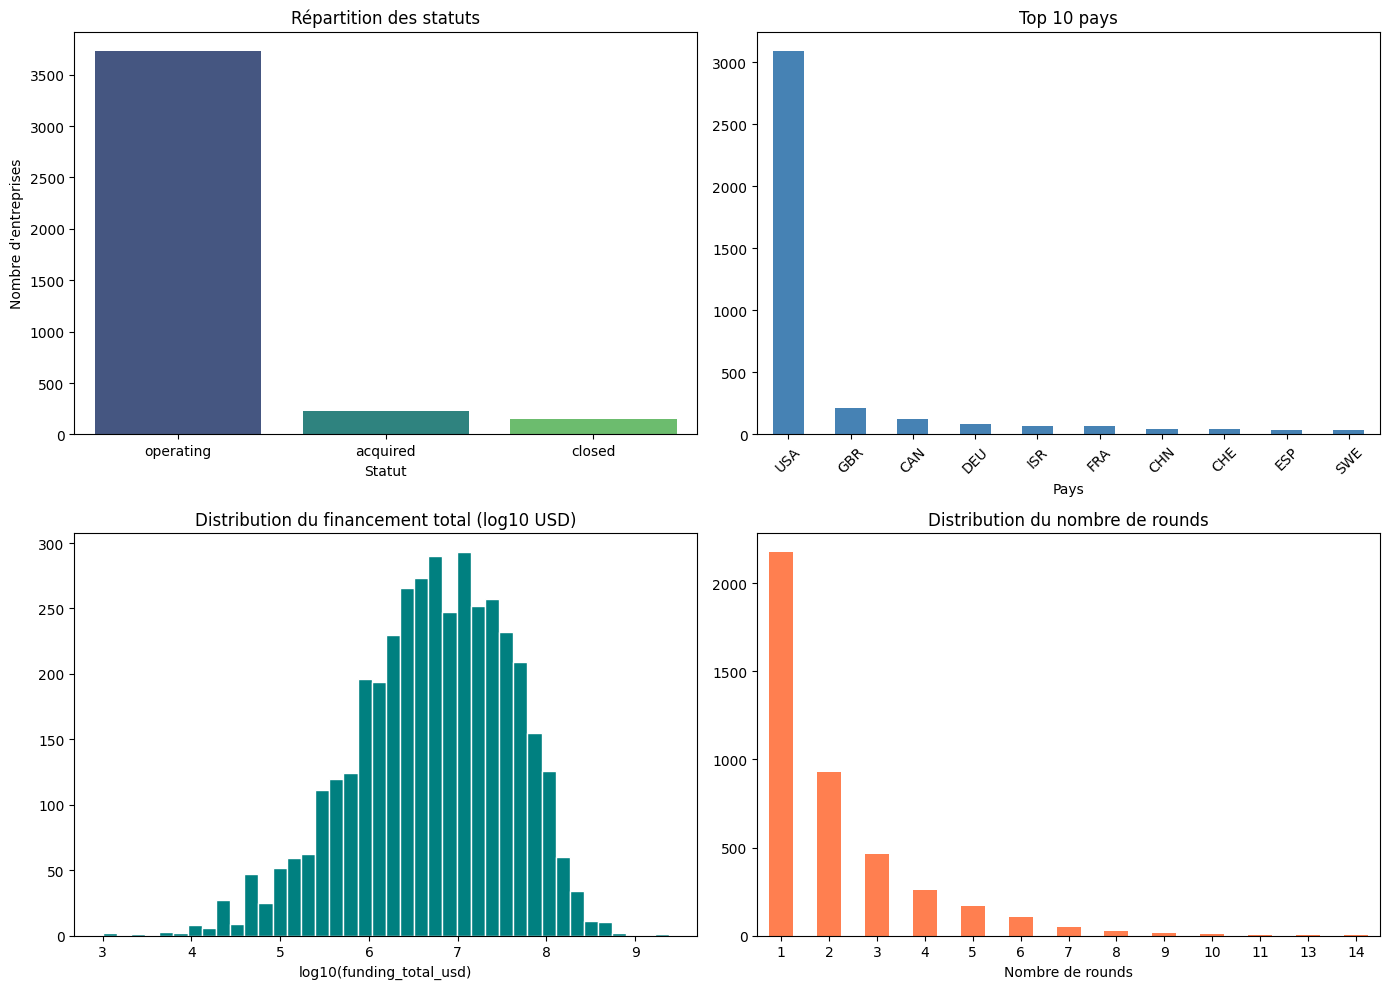

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=pharma_df, x='status', palette='viridis', ax=axes[0,0], hue='status', legend=False)
axes[0,0].set_title('Répartition des statuts')
axes[0,0].set_xlabel('Statut')
axes[0,0].set_ylabel("Nombre d'entreprises")

pharma_df['country_code'].value_counts().head(10).plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Top 10 pays')
axes[0,1].set_xlabel('Pays')
axes[0,1].tick_params(axis='x', rotation=45)

funding_clean = pharma_df['funding_total_usd'].dropna()
funding_clean = funding_clean[funding_clean > 0]
axes[1,0].hist(np.log10(funding_clean), bins=40, color='teal', edgecolor='white')
axes[1,0].set_title('Distribution du financement total (log10 USD)')
axes[1,0].set_xlabel('log10(funding_total_usd)')

pharma_df['funding_rounds'].dropna().astype(int).value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Distribution du nombre de rounds')
axes[1,1].set_xlabel('Nombre de rounds')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
print(pharma_df['status'].unique())

['operating' 'acquired' 'closed' nan]


## 2. Feature Engineering

In [ ]:
CUTOFF = '2012-01-01'
FUNDING_TYPES = ['seed', 'venture', 'grant', 'round_A', 'round_B']
COLS_NUMERIC = ['age', 'funding_total_usd', 'funding_rounds', 'days_to_first_funding',
                'funding_duration', 'funding_velocity', 'round_intensity']
FEATURES = COLS_NUMERIC + [f'has_{c}' for c in FUNDING_TYPES] + ['country_code']

In [ ]:
def build_features(df, reference_date, fit_country_encoder=False, rare_countries=None):
    d = df.copy()
    ref = pd.to_datetime(reference_date)

    d['funding_total_usd'] = pd.to_numeric(d['funding_total_usd'], errors='coerce')
    d['funding_total_usd'] = d['funding_total_usd'].fillna(d['funding_total_usd'].median())

    for col in ['founded_at', 'first_funding_at', 'last_funding_at']:
        d[col] = pd.to_datetime(d[col], errors='coerce')

    d['age'] = ((ref - d['founded_at']).dt.days / 365.25).clip(lower=0.1)
    d['days_to_first_funding'] = (d['first_funding_at'] - d['founded_at']).dt.days
    last_funding_clipped = d['last_funding_at'].clip(upper=ref)
    d['funding_duration'] = (last_funding_clipped - d['first_funding_at']).dt.days

    d['funding_velocity'] = d['funding_total_usd'] / d['age']
    d['round_intensity']  = d['funding_rounds'] / d['age']

    for col in FUNDING_TYPES:
        d[f'has_{col}'] = (d[col].fillna(0) > 0).astype(int)

    for col in COLS_NUMERIC:
        d[col] = d.groupby('market')[col].transform(lambda x: x.fillna(x.median()))
        d[col] = d[col].fillna(d[col].median())

    if fit_country_encoder:
        country_counts = d['country_code'].value_counts()
        rare_countries = country_counts[country_counts < 5].index
    d['country_code'] = d['country_code'].replace(rare_countries, 'OTHER').fillna('UNKNOWN')

    if fit_country_encoder:
        return d, rare_countries
    return d

In [ ]:
ipo_mask = (
    (pd.to_numeric(pharma_df['post_ipo_equity'], errors='coerce') > 0) |
    (pd.to_numeric(pharma_df['post_ipo_debt'], errors='coerce') > 0)
)

train_raw = pharma_df[
    pharma_df['status'].isin(['acquired', 'closed']) |
    ((pharma_df['status'] == 'operating') & ipo_mask)
].copy()

train_data, rare_countries = build_features(train_raw, CUTOFF, fit_country_encoder=True)
train_data['Profitable'] = (
    (train_data['status'] == 'acquired') |
    (train_data['post_ipo_equity'] > 0) |
    (train_data['post_ipo_debt'] > 0)
).astype(int)

print(f"Startups d'entraînement : {len(train_data)}")
print(f"\nÉquilibre des classes :")
print(train_data['Profitable'].value_counts())
print(f"Taux de succès : {train_data['Profitable'].mean():.1%}")

X = pd.get_dummies(train_data[FEATURES], drop_first=True)
y = train_data['Profitable']
print(f"\nFeatures : {X.shape[1]}  |  NaN dans X : {X.isna().sum().sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_pipeline = Pipeline([
    ('imputer', IterativeImputer(random_state=42, max_iter=10)),
    ('scaler', StandardScaler())
])
X_train_s = scaler_pipeline.fit_transform(X_train)
X_test_s  = scaler_pipeline.transform(X_test)

scaler_hgb = Pipeline([
    ('scaler', StandardScaler())
])
from sklearn.impute import SimpleImputer as _SI
_si_tmp = _SI(strategy='median')
X_train_hgb = scaler_hgb.fit_transform(_si_tmp.fit_transform(X_train))
X_test_hgb  = scaler_hgb.transform(_si_tmp.transform(X_test))

Startups d'entraînement : 480

Équilibre des classes :
Profitable
1    333
0    147
Name: count, dtype: int64
Taux de succès : 69.4%

Features : 21  |  NaN dans X : 0


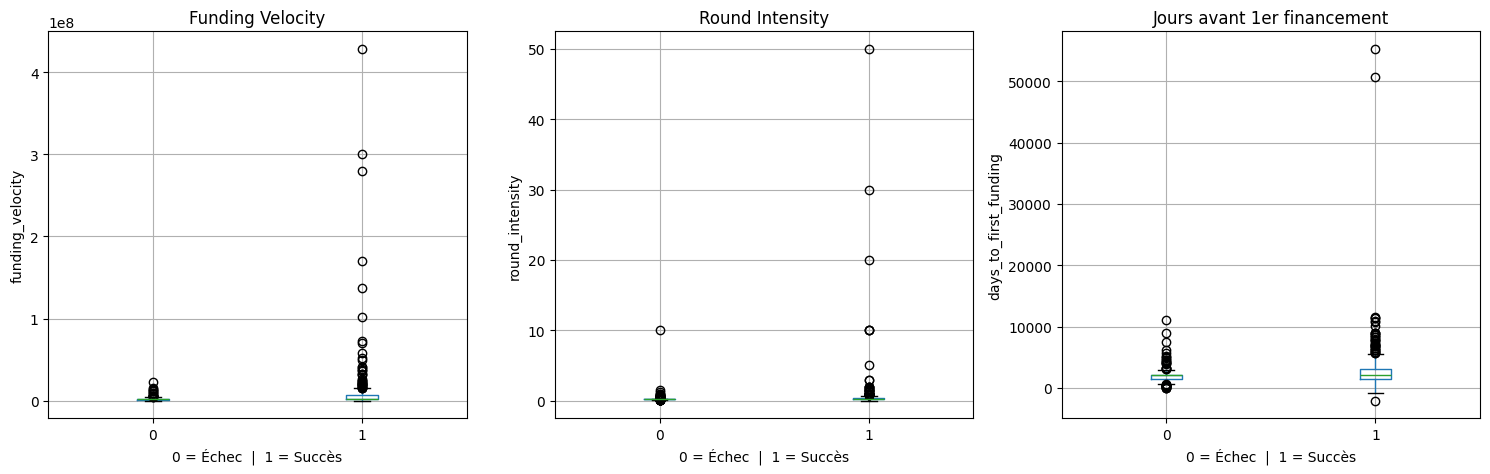

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
    ['funding_velocity', 'round_intensity', 'days_to_first_funding'],
    ['Funding Velocity', 'Round Intensity', 'Jours avant 1er financement']):
    train_data.boxplot(column=col, by='Profitable', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('0 = Échec  |  1 = Succès')
    ax.set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

Funding Velocity : On observe généralement que les startups qui réussissent (1) ont une "Funding Velocity" plus élevée que celles qui échouent (0). Cela suggère que les entreprises capables de lever des fonds plus rapidement par rapport à leur âge ont une plus grande probabilité de succès.

Round Intensity : Similairement, les boxplots montrent que les startups à succès ont tendance à avoir une "Round Intensity" plus forte. Cela signifie qu'elles réalisent plus de tours de financement par rapport à leur âge, indiquant une capacité continue à attirer des investisseurs.

Days to First Funding : Pour cette variable, les boxplots révèlent que les startups à succès (1) tendent à avoir un nombre de jours plus faible entre leur fondation et leur premier financement. Un délai court est interprété comme un indicateur positif, signalant une reconnaissance rapide par les investisseurs et potentiellement une meilleure dynamique de croissance.

## 3. Modèles ML — Baseline

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "Gradient Boosting":   HistGradientBoostingClassifier(class_weight='balanced', max_iter=100, random_state=42),
    "SVM":                 SVC(class_weight='balanced', probability=True, random_state=42)
}

X_train_map = {
    "Logistic Regression": X_train_s,
    "Random Forest":       X_train_s,
    "Gradient Boosting":   X_train_hgb,
    "SVM":                 X_train_s,
}
X_test_map = {
    "Logistic Regression": X_test_s,
    "Random Forest":       X_test_s,
    "Gradient Boosting":   X_test_hgb,
    "SVM":                 X_test_s,
}

results = []

for name, model in models.items():
    X_tr = X_train_map[name]
    X_te = X_test_map[name]
    cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='f1')
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    results.append({
        "Modele":        name,
        "Accuracy":      f"{accuracy_score(y_test, y_pred):.1%}",
        "Precision":     f"{precision_score(y_test, y_pred):.1%}",
        "Recall":        f"{recall_score(y_test, y_pred):.1%}",
        "F1-Score":      f"{f1_score(y_test, y_pred):.1%}",
        "F1-CV (mean)":  f"{cv_scores.mean():.1%}",
        "F1-CV (std)":   f"{cv_scores.std():.1%}",
    })

df_results = pd.DataFrame(results)
print("RÉSULTATS DES MODÈLES")
print(df_results.to_string(index=False))

RÉSULTATS DES MODÈLES
             Modele Accuracy Precision Recall F1-Score F1-CV (mean) F1-CV (std)
Logistic Regression    58.3%     80.0%  53.7%    64.3%        68.2%        5.5%
      Random Forest    68.8%     74.0%  85.1%    79.2%        78.6%        1.5%
  Gradient Boosting    62.5%     77.2%  65.7%    71.0%        74.0%        2.7%
                SVM    59.4%     81.8%  53.7%    64.9%        61.8%        7.7%


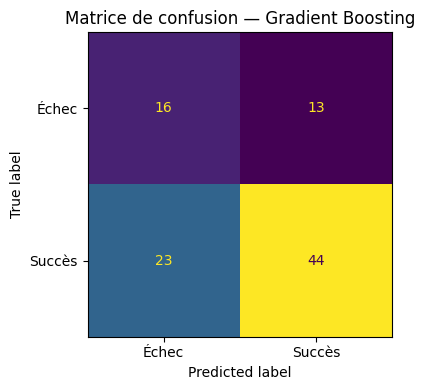

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    models['Gradient Boosting'], X_test_s, y_test,
    display_labels=['Échec', 'Succès'], ax=ax, colorbar=False
)
ax.set_title('Matrice de confusion — Gradient Boosting')
plt.tight_layout()
plt.show()

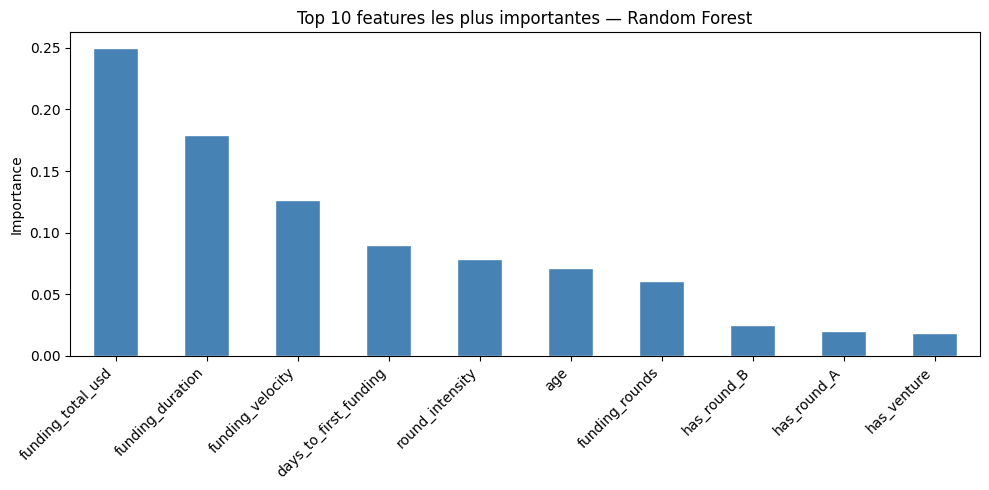

In [ ]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_features.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Top 10 features les plus importantes — Random Forest")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

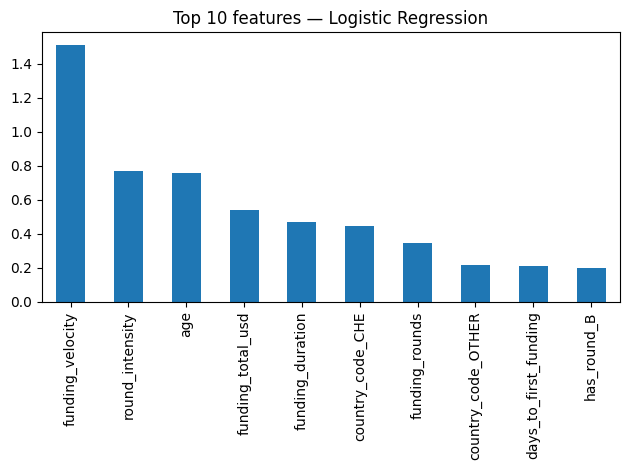

In [ ]:
lr = models["Logistic Regression"]
coefs = pd.Series(np.abs(lr.coef_[0]), index=X.columns)
coefs.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 features — Logistic Regression")
plt.tight_layout()
plt.show()

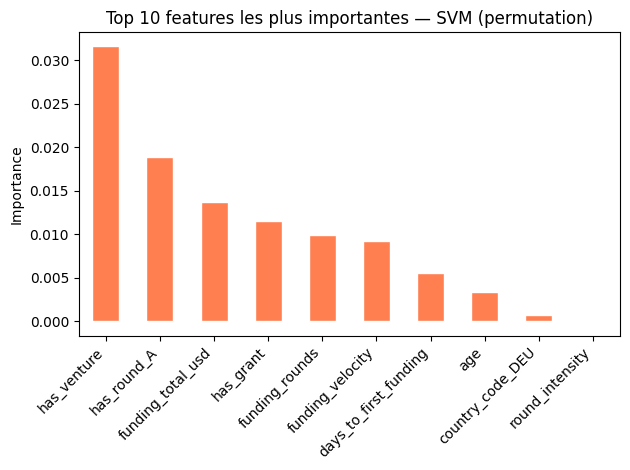

In [ ]:
from sklearn.inspection import permutation_importance

svm = models["SVM"]
perm = permutation_importance(svm, X_test_s, y_test, n_repeats=10, random_state=42, scoring='f1')
svm_importance = pd.Series(perm.importances_mean, index=X.columns)
svm_importance.sort_values(ascending=False).head(10).plot(kind='bar', color='coral', edgecolor='white')
plt.title("Top 10 features les plus importantes — SVM (permutation)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Ensemble pondéré — StackingClassifier

In [ ]:
estimators = [
    ('lr',  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)),
    ('gb',  HistGradientBoostingClassifier(class_weight='balanced', max_iter=100, random_state=42)),
    ('svm', SVC(class_weight='balanced', probability=True, random_state=42))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    passthrough=False
)

stack.fit(X_train_s, y_train)
y_pred_stack = stack.predict(X_test_s)

print("RÉSULTATS — StackingClassifier")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_stack):.1%}")
print(f"Precision : {precision_score(y_test, y_pred_stack):.1%}")
print(f"Recall    : {recall_score(y_test, y_pred_stack):.1%}")
print(f"F1-Score  : {f1_score(y_test, y_pred_stack):.1%}")

import pickle
with open("stack_model.pkl",     "wb") as f: pickle.dump(stack, f)
with open("scaler_pipeline.pkl", "wb") as f: pickle.dump(scaler_pipeline, f)
with open("feature_columns.pkl", "wb") as f: pickle.dump(list(X.columns), f)
print("Artefacts sauvegardés : stack_model.pkl, scaler_pipeline.pkl, feature_columns.pkl")

RÉSULTATS — StackingClassifier
Accuracy  : 67.7%
Precision : 69.6%
Recall    : 95.5%
F1-Score  : 80.5%
Artefacts sauvegardés : stack_model.pkl, scaler_pipeline.pkl, feature_columns.pkl


In [ ]:
meta = stack.final_estimator_
estimator_names = [name for name, _ in stack.estimators]
print(pd.Series(meta.coef_[0], index=estimator_names))

lr     1.518230
rf     0.602889
gb     0.967512
svm   -0.145227
dtype: float64


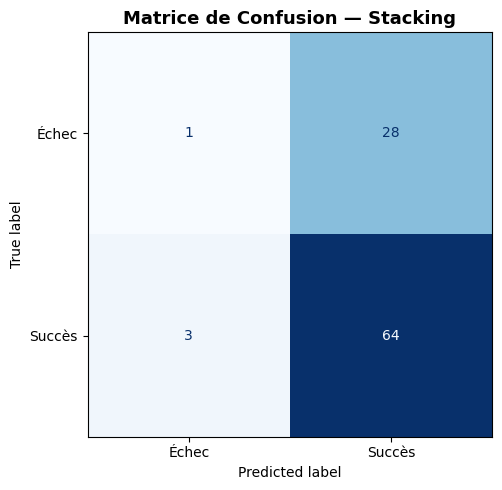

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, stack.predict(X_test_s))
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Échec', 'Succès'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Matrice de Confusion — Stacking", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_stack = cross_val_score(stack, X_train_s, y_train, cv=5, scoring='f1')
print(f"F1 CV 5 folds  : {cv_stack.mean():.3f} ± {cv_stack.std():.3f}")
print(f"F1 Test set    : {f1_score(y_test, stack.predict(X_test_s)):.3f}")
print(f"Écart          : {abs(cv_stack.mean() - f1_score(y_test, stack.predict(X_test_s))):.3f}")

F1 CV 5 folds  : 0.786 ± 0.030
F1 Test set    : 0.805
Écart          : 0.019


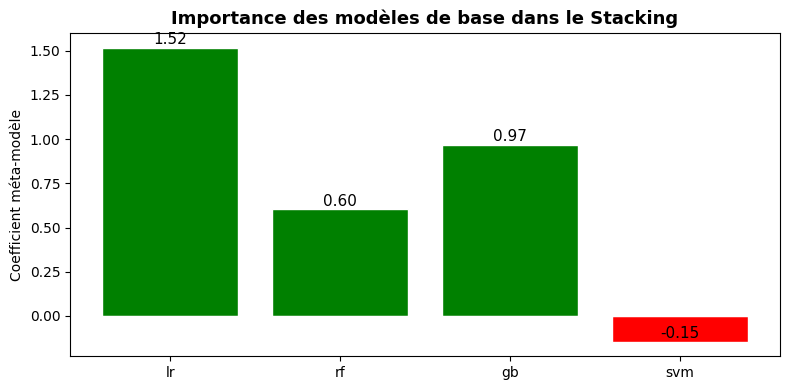

In [ ]:
meta = stack.final_estimator_
estimator_names = [name for name, _ in stack.estimators]
coefs = pd.Series(meta.coef_[0], index=estimator_names)

colors_coef = ['green' if c > 0 else 'red' for c in coefs]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(coefs.index, coefs.values, color=colors_coef, edgecolor='white')
ax.axhline(0, color='white', linewidth=0.8)
ax.set_ylabel("Coefficient méta-modèle")
ax.set_title("Importance des modèles de base dans le Stacking", fontsize=13, fontweight='bold')
for bar, val in zip(bars, coefs.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

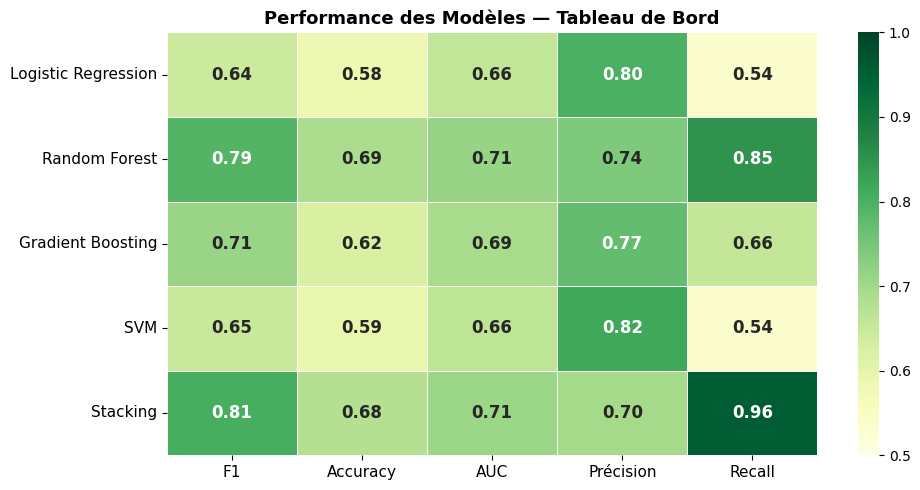

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score

metrics = {}
for name, model in models.items():
    X_te = X_test_hgb if name == "Gradient Boosting" else X_test_s
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    metrics[name] = {
        'F1': f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
        'Précision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
    }

y_pred_stack = stack.predict(X_test_s)
y_proba_stack = stack.predict_proba(X_test_s)[:, 1]
metrics['Stacking'] = {
    'F1': f1_score(y_test, y_pred_stack),
    'Accuracy': accuracy_score(y_test, y_pred_stack),
    'AUC': roc_auc_score(y_test, y_proba_stack),
    'Précision': precision_score(y_test, y_pred_stack),
    'Recall': recall_score(y_test, y_pred_stack),
}

df_metrics = pd.DataFrame(metrics).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_metrics, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, linecolor='white',
            ax=ax, vmin=0.5, vmax=1.0,
            annot_kws={"size": 12, "weight": "bold"})
ax.set_title("Performance des Modèles — Tableau de Bord", fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

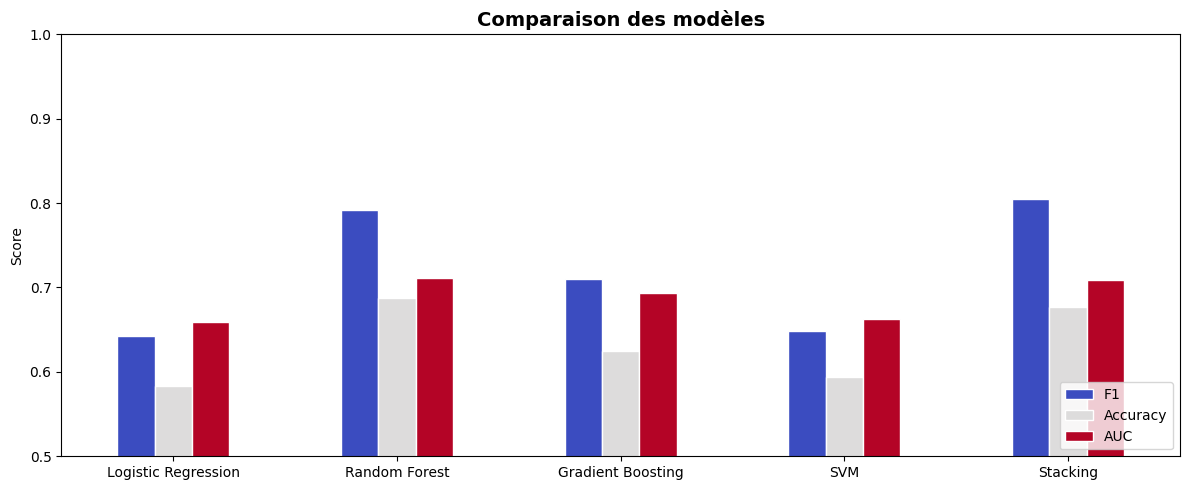

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

metrics = {}
for name, model in models.items():
    X_te = X_test_hgb if name == "Gradient Boosting" else X_test_s
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    metrics[name] = {
        'F1': f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

y_pred_stack = stack.predict(X_test_s)
y_proba_stack = stack.predict_proba(X_test_s)[:, 1]
metrics['Stacking'] = {
    'F1': f1_score(y_test, y_pred_stack),
    'Accuracy': accuracy_score(y_test, y_pred_stack),
    'AUC': roc_auc_score(y_test, y_proba_stack)
}

df_metrics = pd.DataFrame(metrics).T
df_metrics.plot(kind='bar', figsize=(12, 5), colormap='coolwarm', edgecolor='white')
plt.title("Comparaison des modèles", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Scoring du portefeuille actuel (startups 'operating')

In [ ]:
scoring_raw = pharma_df[
    (pharma_df['status'] == 'operating') & ~ipo_mask
].copy()
df_scoring  = build_features(scoring_raw, CUTOFF,
                              fit_country_encoder=False,
                              rare_countries=rare_countries)

X_scoring_raw     = pd.get_dummies(df_scoring[FEATURES], drop_first=True)
X_scoring_aligned = X_scoring_raw.reindex(columns=X.columns, fill_value=0).fillna(0)
X_scoring_scaled  = scaler_pipeline.transform(X_scoring_aligned)

for name, model in models.items():
    df_scoring[f'Score_{name}'] = model.predict_proba(X_scoring_scaled)[:, 1]

score_cols = [f'Score_{m}' for m in models]

df_scoring['Score_Stacking'] = stack.predict_proba(X_scoring_scaled)[:, 1]


cols_display = ['name', 'market', 'Score_Stacking'] + score_cols
top_10 = df_scoring[cols_display].sort_values('Score_Stacking', ascending=False).head(10)

pd.options.display.float_format = '{:.1%}'.format
print("TOP 10 DES STARTUPS LES PLUS PROMETTEUSES")
print(top_10.to_string(index=False))

df_scoring[cols_display].sort_values('Score_Stacking', ascending=False).to_csv(
    "startups_scoring_final.csv", index=False, float_format='%.4f')
print("\nFichier exporté : startups_scoring_final.csv")

TOP 10 DES STARTUPS LES PLUS PROMETTEUSES
                  name            market  Score_Stacking  Score_Logistic Regression  Score_Random Forest  Score_Gradient Boosting  Score_SVM
         Loxo Oncology    Biotechnology            89.5%                     100.0%               100.0%                   100.0%      76.3%
    Spark Therapeutics    Biotechnology            89.5%                     100.0%               100.0%                    99.9%      76.2%
              TELA Bio    Biotechnology            89.5%                     100.0%               100.0%                   100.0%      76.6%
     Amal Therapeutics    Biotechnology            89.4%                     100.0%               100.0%                    99.8%      78.2%
           Flex Pharma  Pharmaceuticals            89.4%                     100.0%               100.0%                    99.7%      79.1%
 Audentes Therapeutics    Biotechnology            89.4%                     100.0%                99.0%        

## 7. Analyse Éthique — Pipeline NLP (ESG-BERT)

In [ ]:
class MultiSourceEthicalExtractor:
    """Collecte de données textuelles depuis ClinicalTrials.gov, PubMed et sites web."""

    CLINICAL_TRIALS_BASE = "https://clinicaltrials.gov/api/v2/studies"
    PUBMED_BASE          = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
    HEADERS              = {'User-Agent': 'Mozilla/5.0'}

    def search_clinical_trials(self, startup_name: str, max_studies: int = 50) -> List[Dict]:
        queries = [
            f'AREA[OverallStatus]COMPLETED AND AREA[LeadSponsorName]"{startup_name}"',
            f'AREA[OverallStatus]COMPLETED AND AREA[CollaboratorName]"{startup_name}"',
        ]
        nct_ids = list({
            nct_id
            for q in queries
            for nct_id in self._search_nct_ids(q, max_studies)
        })
        print(f"[{startup_name}] ClinicalTrials : {len(nct_ids)} essais identifiés")
        return [d for nct_id in nct_ids if (d := self._extract_study_data(nct_id))]

    def _search_nct_ids(self, query: str, max_studies: int) -> List[str]:
        params = {"query.term": query, "pageSize": min(max_studies, 1000), "format": "json"}
        try:
            r = requests.get(self.CLINICAL_TRIALS_BASE, params=params, timeout=30)
            r.raise_for_status()
            return [s['protocolSection']['identificationModule']['nctId']
                    for s in r.json().get('studies', [])]
        except Exception:
            return []

    def _extract_study_data(self, nct_id: str) -> Dict | None:
        try:
            r = requests.get(f"{self.CLINICAL_TRIALS_BASE}/{nct_id}",
                             params={"format": "json"}, timeout=30)
            s = r.json().get('protocolSection', {})
            return {
                'source':      'clinicaltrials',
                'title':       s.get('identificationModule', {}).get('officialTitle', ''),
                'description': s.get('descriptionModule', {}).get('briefSummary', ''),
                'eligibility': s.get('eligibilityModule', {}).get('eligibilityCriteria', ''),
            }
        except Exception:
            return None

    def search_pubmed(self, startup_name: str, max_articles: int = 20) -> List[Dict]:
        try:
            search_r = requests.get(
                f"{self.PUBMED_BASE}/esearch.fcgi",
                params={'db': 'pubmed', 'term': f'"{startup_name}"[Affiliation]',
                        'retmax': max_articles, 'retmode': 'json'}, timeout=30)
            search_r.raise_for_status()
            pmids = search_r.json().get('esearchresult', {}).get('idlist', [])
            print(f"[{startup_name}] PubMed : {len(pmids)} publications trouvées")
            if not pmids:
                return []
            fetch_r = requests.get(
                f"{self.PUBMED_BASE}/efetch.fcgi",
                params={'db': 'pubmed', 'id': ','.join(pmids), 'retmode': 'xml'}, timeout=30)
            soup = BeautifulSoup(fetch_r.content, 'xml')
            articles = []
            for article in soup.find_all('PubmedArticle'):
                title_tag    = article.find('ArticleTitle')
                abstract_tag = article.find('AbstractText')
                articles.append({
                    'source':      'pubmed',
                    'title':       title_tag.text if title_tag else '',
                    'description': abstract_tag.text if abstract_tag else '',
                    'eligibility': '',
                })
            time.sleep(0.5)
            return articles[:max_articles]
        except Exception as e:
            print(f"[{startup_name}] PubMed erreur : {e}")
            return []

    def search_company_website(self, startup_name: str) -> str | None:
      """Trouve l'URL officielle via DuckDuckGo HTML."""
      try:
        r = requests.get(
            "https://html.duckduckgo.com/html/",
            params={'q': f"{startup_name} official website"},
            headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'},
            timeout=10
        )
        soup = BeautifulSoup(r.text, 'html.parser')

        first = soup.select_one('.result__url')
        if first:
            url = first.get_text(strip=True)
            if not url.startswith('http'):
                url = 'https://' + url
            return url
        return None
      except Exception:
        return None

    def scrape_company_website(self, startup_name: str, website_url: str = None) -> Dict | None:
        base = website_url or self.search_company_website(startup_name) or f"https://{startup_name.lower().replace(' ', '')}.com"
        paths = ['', '/about', '/en/us/company', '/company', '/about-us', '/who-we-are']

        for path in paths:
            url = base + path
            try:
                r = requests.get(url, headers=self.HEADERS, timeout=10)
                r.raise_for_status()
                page_text = BeautifulSoup(r.content, 'html.parser').get_text(separator=' ', strip=True)
                keywords  = ['mission', 'values', 'diversity', 'inclusion', 'ethics', 'team', 'culture']
                excerpts  = [m for kw in keywords
                             for m in re.findall(rf'.{{0,200}}{kw}.{{0,200}}', page_text, re.IGNORECASE)]
                if excerpts:
                    time.sleep(1)
                    return {
                        'source':      'website',
                        'title':       f"{startup_name} - Mission & Values",
                        'description': ' | '.join(excerpts[:5])[:1000],
                        'eligibility': '',
                    }
            except Exception:
                continue

        return None

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("nbroad/ESG-BERT")
esg_model = AutoModelForSequenceClassification.from_pretrained("nbroad/ESG-BERT")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nbroad/ESG-BERT
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
ESG_LABELS = [
    "Climate Change", "Natural Capital", "Pollution & Waste", "Water Security",
    "Human Capital", "Product Liability", "Community Relations", "Corporate Governance",
    "Business Ethics & Values", "Supply Chain Management", "Labor Relations",
    "Diversity & Inclusion", "Human Rights", "Environmental Policy", "Energy",
    "Renewable Energy", "Carbon Emissions", "Biodiversity", "Data Privacy",
    "Executive Compensation", "Shareholder Rights", "Audit", "Anti-Corruption",
    "Child Labor", "Employee Health & Safety", "Tax Transparency"
]

class ESGScorer:
    """Scoring éthique via ESG-BERT (nbroad/ESG-BERT)."""

    def compute_ethical_score(self, all_sources_data: List[Dict]) -> Dict:
        if not all_sources_data:
            return {
                'ethical_investment_index': 0.0,
                'esg_top_category':         'N/A',
                'esg_top3':                 'N/A',
                'sentiment_score':          0.5,
                'adjusted_ethical_score':   0.0,
                'num_sources':              0,
                'data_quality_score':       0.0
            }

        full_text = " ".join([
            d.get('title', '') + " " + d.get('description', '')
            for d in all_sources_data
        ])

        inputs = tokenizer(full_text, return_tensors="pt", truncation=True, max_length=512)

        with torch.no_grad():
            outputs = esg_model(**inputs)

        probs = torch.softmax(outputs.logits, dim=1).squeeze().tolist()

        top_idx          = int(np.argmax(probs))
        raw_esg_score    = round(probs[top_idx], 4)
        esg_top_category = ESG_LABELS[top_idx]
        top3_idx         = np.argsort(probs)[::-1][:3]
        esg_top3         = ", ".join([f"{ESG_LABELS[i]} ({probs[i]:.2f})" for i in top3_idx])


        sentiment_score = self._compute_sentiment(full_text)

        return {
            'ethical_investment_index': raw_esg_score,
            'esg_top_category':         esg_top_category,
            'esg_top3':                 esg_top3,
            'sentiment_score':          round(sentiment_score, 4),
            'adjusted_ethical_score':   round(raw_esg_score * (0.7 + 0.3 * sentiment_score), 4),
            'num_sources':              len(all_sources_data),
            'data_quality_score':       min(len(all_sources_data) / 30, 1.0)
        }

    def _compute_sentiment(self, text: str) -> float:
        """Score de sentiment entre 0 (négatif) et 1 (positif) via DistilBERT."""
        if not text or len(text.strip()) == 0:
            return 0.5
        try:
            from transformers import pipeline as hf_pipeline
            _sentiment = hf_pipeline(
                "sentiment-analysis",
                model="distilbert-base-uncased-finetuned-sst-2-english"
            )
            chunks = [text[j:j+400] for j in range(0, min(len(text), 1200), 400)]
            scores = []
            for chunk in chunks:
                res = _sentiment(chunk)[0]
                s = res['score'] if res['label'] == 'POSITIVE' else 1 - res['score']
                scores.append(s)
            return float(np.mean(scores))
        except Exception:
            return 0.5

In [ ]:
def run_ethical_scoring(startup_list: List[Dict], output_file: str = "ethical_scores.csv") -> pd.DataFrame:
    extractor = MultiSourceEthicalExtractor()
    scorer    = ESGScorer()
    results   = []


    print(f"Lancement du pipeline pour {len(startup_list)} entreprises")

    for i, startup in enumerate(startup_list, 1):
        name    = startup['name']
        website = startup.get('website')
        print(f"--- [{i}/{len(startup_list)}] Traitement : {name} ---")

        all_data = []
        all_data.extend(extractor.search_clinical_trials(name))
        all_data.extend(extractor.search_pubmed(name))
        if web_data := extractor.scrape_company_website(name, website):
            all_data.append(web_data)

        scores = scorer.compute_ethical_score(all_data)
        results.append({
            'startup_name':             name,
            'total_sources':            scores['num_sources'],
            'ethical_investment_index': scores['ethical_investment_index'],
            'esg_top_category':         scores.get('esg_top_category', 'N/A'),
            'esg_top3':                 scores.get('esg_top3', 'N/A'),
            'sentiment_score':          scores.get('sentiment_score', 0.5),
            'adjusted_ethical_score':   scores.get('adjusted_ethical_score', scores['ethical_investment_index']),
            'data_quality_score':       scores['data_quality_score'],
        })
        time.sleep(2)

    df = pd.DataFrame(results).sort_values('ethical_investment_index', ascending=False)
    df.to_csv(output_file, index=False)
    print(f"Opération terminée. Fichier généré : {output_file}")
    return df

top_20_names = df_scoring.sort_values('Score_Stacking', ascending=False).head(20)['name'].tolist()
startups_to_score = [{'name': name, 'website': None} for name in top_20_names]
df_final_ethical = run_ethical_scoring(startups_to_score)


Lancement du pipeline pour 20 entreprises
--- [1/20] Traitement : Loxo Oncology ---
[Loxo Oncology] ClinicalTrials : 39 essais identifiés
[Loxo Oncology] PubMed : 20 publications trouvées


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

--- [19/20] Traitement : AlixaRx ---
[AlixaRx] ClinicalTrials : 0 essais identifiés
[AlixaRx] PubMed : 0 publications trouvées


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

--- [20/20] Traitement : Abeona Therapeutics ---
[Abeona Therapeutics] ClinicalTrials : 5 essais identifiés
[Abeona Therapeutics] PubMed : 9 publications trouvées


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Opération terminée. Fichier généré : ethical_scores.csv


In [ ]:
ethical_scores = pd.read_csv("ethical_scores.csv", encoding='latin1')
ethical_scores

,startup_name,total_sources,ethical_investment_index,esg_top_category,esg_top3,sentiment_score,adjusted_ethical_score,data_quality_score
0,DistalMotion,9,83.5%,Supply Chain Management,"Supply Chain Management (0.83), Business Ethic...",96.3%,82.6%,30.0%
1,TELA Bio,5,80.0%,Supply Chain Management,"Supply Chain Management (0.80), Business Ethic...",38.1%,65.1%,16.7%
2,AlixaRx,1,52.7%,Energy,"Energy (0.53), Community Relations (0.12), Ren...",99.4%,52.6%,3.3%
3,AVEO Pharmaceuticals,47,39.6%,Community Relations,"Community Relations (0.40), Human Capital (0.0...",22.9%,30.4%,100.0%
4,Loxo Oncology,60,36.6%,Carbon Emissions,"Carbon Emissions (0.37), Community Relations (...",7.6%,26.4%,100.0%
5,Zynerba Pharmaceuticals,17,36.3%,Energy,"Energy (0.36), Community Relations (0.16), Car...",37.7%,29.5%,56.7%
6,Patara Pharma,4,35.9%,Energy,"Energy (0.36), Community Relations (0.16), Car...",6.0%,25.8%,13.3%
7,IsoPlexis,21,29.8%,Carbon Emissions,"Carbon Emissions (0.30), Community Relations (...",66.4%,26.8%,70.0%
8,Audentes Therapeutics,24,29.4%,Supply Chain Management,"Supply Chain Management (0.29), Business Ethic...",17.3%,22.1%,80.0%
9,BioMotiv,2,27.9%,Supply Chain Management,"Supply Chain Management (0.28), Product Liabil...",21.4%,21.3%,6.7%


## 8. Fusion Score Financier + Score Éthique

In [ ]:
ethical_scores = pd.read_csv("ethical_scores.csv")

df_final = df_scoring[['name', 'market', 'Score_Stacking']].merge(
    ethical_scores[['startup_name', 'ethical_investment_index', 'esg_top_category', 'esg_top3',
                    'sentiment_score', 'adjusted_ethical_score', 'data_quality_score']],
    left_on='name', right_on='startup_name', how='left'
).drop(columns='startup_name')

df_final['ethical_investment_index'] = df_final['ethical_investment_index'].fillna(0)
df_final['adjusted_ethical_score']   = df_final['adjusted_ethical_score'].fillna(0)
df_final['sentiment_score']          = df_final['sentiment_score'].fillna(0.5)
df_final['data_quality_score']       = df_final['data_quality_score'].fillna(0)

df_final['Score_Final'] = (
    0.9 * df_final['Score_Stacking'] +
    0.1 * df_final['adjusted_ethical_score'] * df_final['data_quality_score']
)

df_final['sentiment_label'] = df_final['sentiment_score'].apply(
    lambda s: 'Positif' if s >= 0.6 else ('Négatif' if s <= 0.4 else 'Neutre')
)

cols_display = ['name', 'market', 'Score_Stacking',
                'ethical_investment_index', 'esg_top_category', 'esg_top3',
                'sentiment_score', 'sentiment_label',
                'adjusted_ethical_score', 'data_quality_score', 'Score_Final']
top_final = df_final[cols_display].sort_values('Score_Final', ascending=False).head(10)
pd.options.display.float_format = '{:.1%}'.format
print("TOP 10 FINAL — Score Financier + Éthique (ajusté par sentiment)")
print(top_final.to_string(index=False))

df_final[cols_display].sort_values('Score_Final', ascending=False).to_csv(
    "ranking_final.csv", index=False, float_format='%.4f')
print("\nFichier exporté : ranking_final.csv")

print("\n--- Entraînement avec score éthique comme feature ML ---")

train_enriched = train_data.merge(
    ethical_scores[['startup_name', 'adjusted_ethical_score', 'sentiment_score']],
    left_on='name', right_on='startup_name', how='left'
).fillna({'adjusted_ethical_score': 0, 'sentiment_score': 0.5})

FEATURES_ENRICHED = FEATURES + ['adjusted_ethical_score', 'sentiment_score']
X_enrich = pd.get_dummies(train_enriched[FEATURES], drop_first=True)
X_enrich['adjusted_ethical_score'] = train_enriched['adjusted_ethical_score'].values
X_enrich['sentiment_score']        = train_enriched['sentiment_score'].values
y_enrich = train_enriched['Profitable']

X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(
    X_enrich, y_enrich, test_size=0.2, random_state=42, stratify=y_enrich
)
pipe_enrich = Pipeline([
    ('imputer', IterativeImputer(random_state=42, max_iter=10)),
    ('scaler',  StandardScaler())
])
X_tr_e_s = pipe_enrich.fit_transform(X_tr_e)
X_te_e_s = pipe_enrich.transform(X_te_e)

stack_enriched = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)),
        ('gb', HistGradientBoostingClassifier(class_weight='balanced', max_iter=100, random_state=42)),
    ],
    final_estimator=LogisticRegression(),
    cv=5
)
stack_enriched.fit(X_tr_e_s, y_tr_e)
y_pred_enrich = stack_enriched.predict(X_te_e_s)

print("Stacking + score éthique comme feature ML :")
print(f"  Accuracy  : {accuracy_score(y_te_e, y_pred_enrich):.1%}")
print(f"  Precision : {precision_score(y_te_e, y_pred_enrich):.1%}")
print(f"  Recall    : {recall_score(y_te_e, y_pred_enrich):.1%}")
print(f"  F1-Score  : {f1_score(y_te_e, y_pred_enrich):.1%}")


with open("stack_enriched.pkl",           "wb") as f: pickle.dump(stack_enriched, f)
with open("pipe_enrich.pkl",              "wb") as f: pickle.dump(pipe_enrich, f)
with open("feature_columns_enriched.pkl", "wb") as f: pickle.dump(list(X_enrich.columns), f)
print("Artefacts enrichis sauvegardés : stack_enriched.pkl, pipe_enrich.pkl, feature_columns_enriched.pkl")

TOP 10 FINAL — Score Financier + Éthique (ajusté par sentiment)
                   name            market  Score_Stacking  ethical_investment_index        esg_top_category                                                                                  esg_top3  sentiment_score sentiment_label  adjusted_ethical_score  data_quality_score  Score_Final
   AVEO Pharmaceuticals      Health Care            89.3%                     39.6%     Community Relations                 Community Relations (0.40), Human Capital (0.09), Carbon Emissions (0.07)            22.9%         Négatif                   30.4%              100.0%        83.5%
          Loxo Oncology    Biotechnology            89.5%                     36.6%        Carbon Emissions                        Carbon Emissions (0.37), Community Relations (0.31), Energy (0.08)             7.6%         Négatif                   26.4%              100.0%        83.2%
           DistalMotion    Biotechnology            89.3%               

In [ ]:
from google.colab import files
files.download("ranking_final.csv")
files.download("startups_scoring_final.csv")
files.download("ethical_scores.csv")
files.download("stack_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

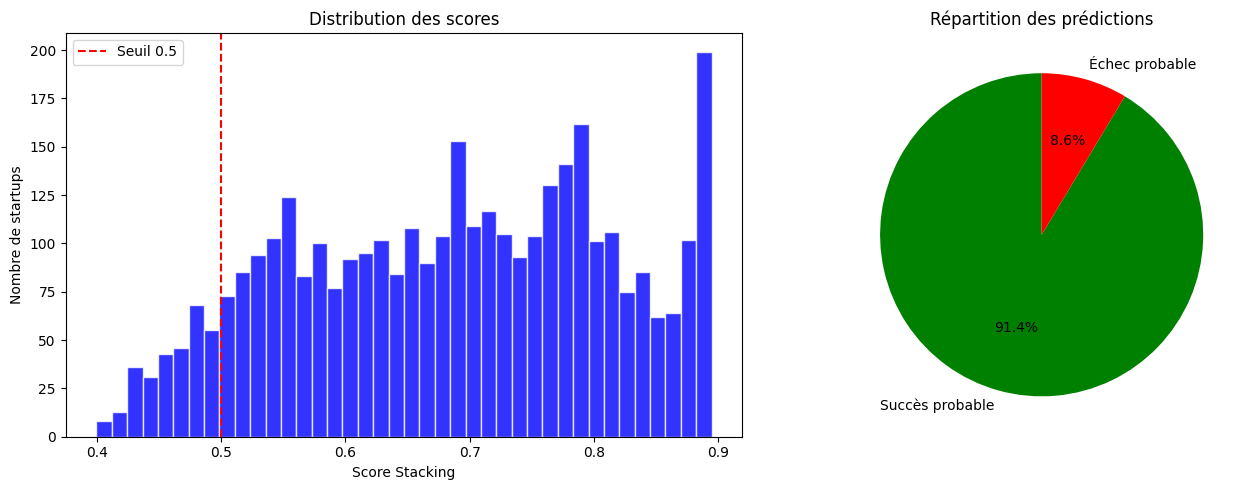

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_scoring['Score_Stacking'], bins=40, color='blue', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', label='Seuil 0.5')
axes[0].set_xlabel("Score Stacking")
axes[0].set_ylabel("Nombre de startups")
axes[0].set_title("Distribution des scores")
axes[0].legend()

counts = [(df_scoring['Score_Stacking'] >= 0.5).sum(), (df_scoring['Score_Stacking'] < 0.5).sum()]
axes[1].pie(counts, labels=['Succès probable', 'Échec probable'],
            autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
axes[1].set_title("Répartition des prédictions")

plt.tight_layout()
plt.show()

/tmp/ipykernel_782/3628052606.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='market', y='Score_Final', palette='coolwarm')


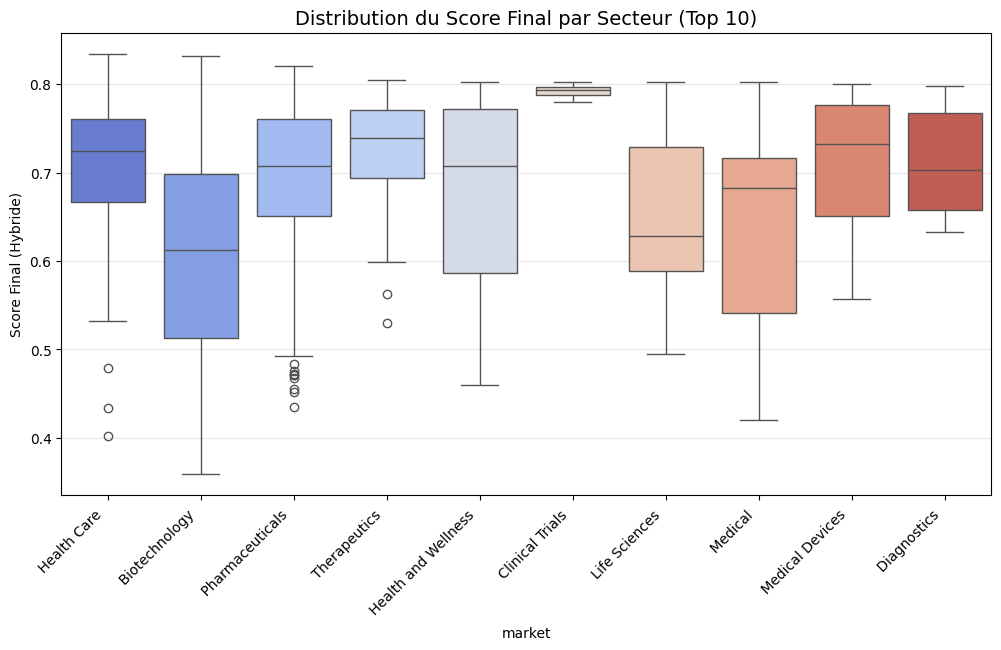

In [ ]:
df = pd.read_csv('ranking_final.csv')

plt.figure(figsize=(12, 6))
top_markets = df['market'].value_counts().nlargest(10).index
df_plot = df[df['market'].isin(top_markets)]

sns.boxplot(data=df_plot, x='market', y='Score_Final', palette='coolwarm')
plt.title('Distribution du Score Final par Secteur (Top 10)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Score Final (Hybride)')
plt.grid(axis='y', alpha=0.3)
plt.show()

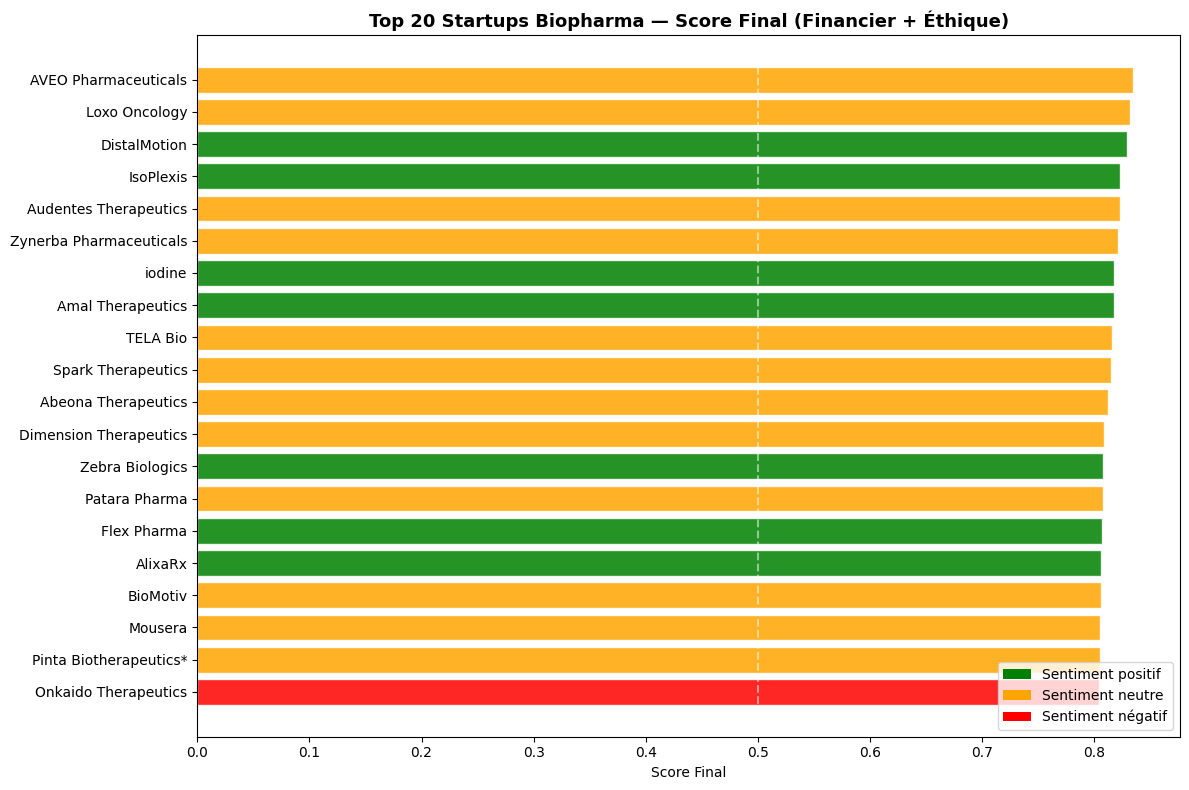

In [ ]:
top20 = df_final.sort_values('Score_Final', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors_bar = top20['sentiment_score'][::-1].apply(
    lambda s: 'green' if s >= 0.6 else ('orange' if s <= 0.4 else 'red')
)
ax.barh(top20['name'][::-1], top20['Score_Final'][::-1], color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(0.5, color='white', linestyle='--', alpha=0.5)
ax.set_xlabel("Score Final")
ax.set_title("Top 20 Startups Biopharma — Score Final (Financier + Éthique)", fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Sentiment positif'),
                   Patch(facecolor='orange', label='Sentiment neutre'),
                   Patch(facecolor='red', label='Sentiment négatif')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

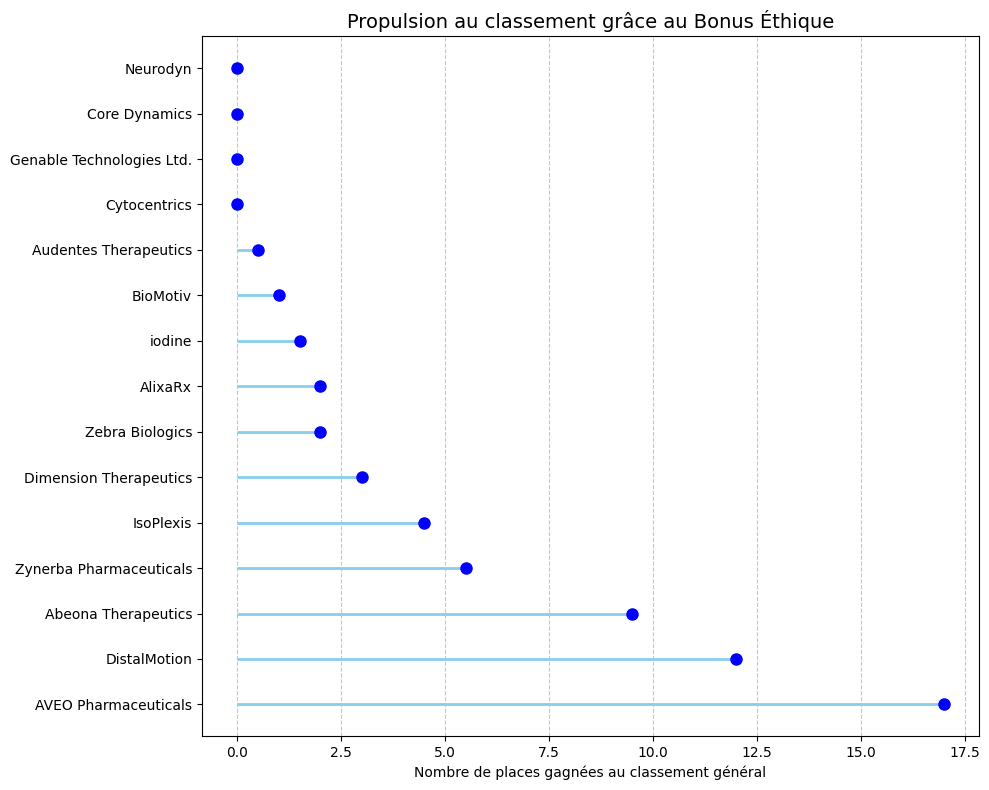

In [ ]:
df['Rank_ML'] = df['Score_Stacking'].rank(ascending=False)
df['Score_Final_10'] = (df['Score_Stacking'] * 0.9) + (df['adjusted_ethical_score'] * df['data_quality_score'] * 0.1)
df['Rank_Final'] = df['Score_Final_10'].rank(ascending=False)
df['Gain_Places'] = df['Rank_ML'] - df['Rank_Final']

top_boost = df.sort_values('Gain_Places', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.hlines(y=top_boost['name'], xmin=0, xmax=top_boost['Gain_Places'], color='skyblue', linewidth=2)
plt.plot(top_boost['Gain_Places'], top_boost['name'], "o", markersize=8, color='blue')
plt.title('Propulsion au classement grâce au Bonus Éthique', fontsize=14)
plt.xlabel('Nombre de places gagnées au classement général')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

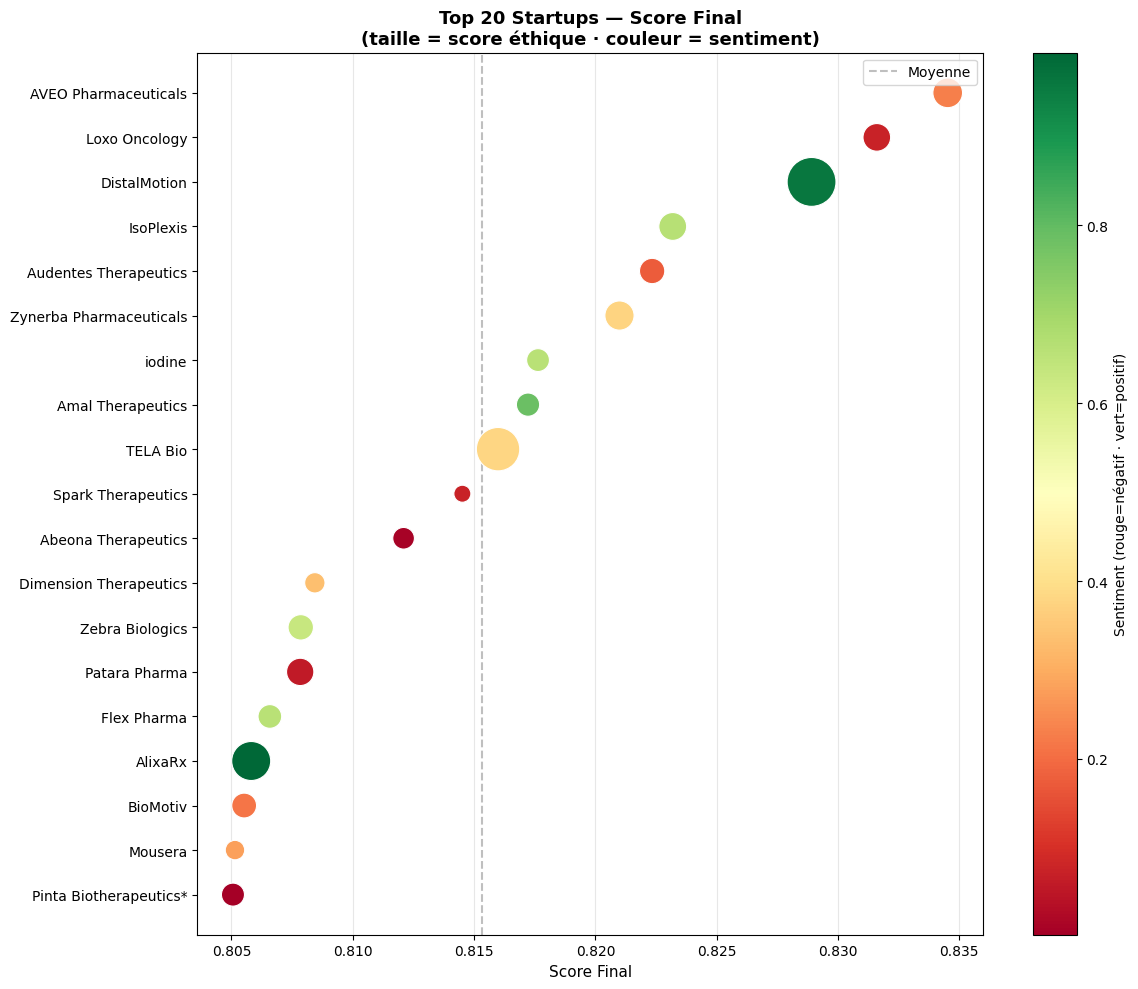

In [ ]:
df_scatter = df_final[df_final['adjusted_ethical_score'] > 0].copy()
df_scatter = df_scatter.sort_values('Score_Final', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    df_scatter['Score_Final'],
    range(len(df_scatter)),
    s=df_scatter['adjusted_ethical_score'] * 1500,
    c=df_scatter['sentiment_score'],
    cmap='RdYlGn', edgecolors='white', linewidth=0.8, zorder=3
)

ax.set_yticks(range(len(df_scatter)))
ax.set_yticklabels(df_scatter['name'], fontsize=10)
ax.set_xlabel("Score Final", fontsize=11)
ax.set_title("Top 20 Startups — Score Final\n(taille = score éthique · couleur = sentiment)", fontsize=13, fontweight='bold')

plt.colorbar(scatter, label='Sentiment (rouge=négatif · vert=positif)')
ax.axvline(df_scatter['Score_Final'].mean(), color='gray', linestyle='--', alpha=0.5, label='Moyenne')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()